<h1>DSCI 100 Final Project</h1>
<h3>Section 008 Group 19</h3>
<h5>Name: Camille S, Chloe Lin, Erica, Seerat Waraich</h5>

<h2>Introduction:</h2>
general question and specfic question. Basic explaination of what wrangling we will do, and possible issues.

<h2>Method & Results:</h2>
<h3>1. Load Data</h3>

In [2]:
#cell for loading packages
library(tidyverse)
library(tidymodels)
library(repr)
library(ggplot2)
library(themis)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
── Attaching packages ────────────────────────────────────── tidymodels 1.1.1 ──

✔ broom        1.0.6     ✔ rsample      1.2.1
✔ dials        1.3.0     ✔ tune         1.1.2
✔ infer        1.0.7     ✔ workflows    1.1.4
✔ modeldata    1.4.0     ✔ workflowsets 1.0.1
✔ parsnip      1.2.1     ✔ yardstick    1.3.1
✔ recipes      1.1.0     

── Conflicts ───────────────────────────────────────── tidymodels_conflicts() ──
✖ scales::discard() masks purrr::discard()
✖ dplyr::filt

In [3]:
url <- "https://raw.githubusercontent.com/camillesnyder/Final-Project/refs/heads/main/players.csv"
download.file( url, destfile = "players.csv")
players_data <- read_csv("players.csv")

head(players_data)

Rows: 196 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): experience, hashedEmail, name, gender
dbl (2): played_hours, Age
lgl (1): subscribe

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


experience,subscribe,hashedEmail,played_hours,name,gender,Age
<chr>,<lgl>,<chr>,<dbl>,<chr>,<chr>,<dbl>
Pro,TRUE,f6daba428a5e19a3d47574858c13550499be23603422e6a0ee9728f8b53e192d,30.3,Morgan,Male,9
Veteran,TRUE,f3c813577c458ba0dfef80996f8f32c93b6e8af1fa939732842f2312358a88e9,3.8,Christian,Male,17
Veteran,FALSE,b674dd7ee0d24096d1c019615ce4d12b20fcbff12d79d3c5a9d2118eb7ccbb28,0.0,Blake,Male,17
Amateur,TRUE,23fe711e0e3b77f1da7aa221ab1192afe21648d47d2b4fa7a5a659ff443a0eb5,0.7,Flora,Female,21
Regular,TRUE,7dc01f10bf20671ecfccdac23812b1b415acd42c2147cb0af4d48fcce2420f3e,0.1,Kylie,Male,21
Amateur,TRUE,f58aad5996a435f16b0284a3b267f973f9af99e7a89bee0430055a44fa92f977,0.0,Adrian,Female,17


<h3>2. Data Cleaning and Wrangling</h3>

In [4]:
#wrangling data by changing experience, subscribe to a numerical vector so straight-line calculations can be performed
#selecting played_hours vector, experience vector, and Age vector as predictors, and subscribe variable as the response
#filtering out NA values so they doesn't mess up calculations
players_wrang <- players_data|>
    select(played_hours, experience, Age, subscribe)|>
    mutate( experience = as_factor(experience))|>
    mutate( experience = fct_recode(experience,
                                    "1" = "Beginner",
                                    "2" = "Amateur",
                                    "3" = "Regular",
                                    "4" = "Veteran",
                                    "5" = "Pro"))|>
    mutate(experience = as.numeric(experience))|>
    mutate(subscribe = as_factor(subscribe))|>
    drop_na()

### 3. Data Summary

#### players_data:

In [5]:
summary(players_data)

  experience        subscribe       hashedEmail         played_hours    
 Length:196         Mode :logical   Length:196         Min.   :  0.000  
 Class :character   FALSE:52        Class :character   1st Qu.:  0.000  
 Mode  :character   TRUE :144       Mode  :character   Median :  0.100  
                                                       Mean   :  5.846  
                                                       3rd Qu.:  0.600  
                                                       Max.   :223.100  
                                                                        
     name              gender               Age       
 Length:196         Length:196         Min.   : 9.00  
 Class :character   Class :character   1st Qu.:17.00  
 Mode  :character   Mode  :character   Median :19.00  
                                       Mean   :21.14  
                                       3rd Qu.:22.75  
                                       Max.   :58.00  
                               

|           |          |          |
| :-------- | :------- | :------- |
| **experience**  | character | players' experience levels in-game classified into levels: “Amateur”, “Beginner”, “Pro”, “Regular”, “Veteran” |
| **subscribe** |logical |  whether players subscribe to a game-related newsletter, indicated with TRUE and FALSE     |
| **hashedEmail**    |character | players’ email address    |
| **played_hours**      |numerical | players’ total play time (in hours) |
| **name**              |character |players' names|
| **gender**            |character | players' gender |
| **Age**               |numerical | players' age|

#### Players' Subscription Counts

In [17]:
players_data |> count(subscribe)

subscribe,n
<lgl>,<int>
FALSE,52
TRUE,144


Above shows the number of players who subscribed to the game-related newsletter and those who did not. There are more subscribers than non-subscribers in this dataset, which means the classes are not perfectly balanced, it is important to keep in mind when using it as response variable in modelling, because unequal class sizes may influence while doing prediction.

#### Players' Experience Levels Counts

In [6]:
players_data |> count(experience)

experience,n
<chr>,<int>
Amateur,63
Beginner,35
Pro,14
Regular,36
Veteran,48


Above shows the number of players in each experience levels in-game.

#### Subscription Rate of Players

In [18]:
# Subscription Rate of players
proportion_of_subscribed <- players_data|>
    summarize(proportion_subscribed = sum(subscribe == "TRUE")/196)

proportion_of_subscribed

proportion_subscribed
<dbl>
0.7346939


#### Mean of [experience], [Age], & [subscribe]

In [19]:
# Mean of [experience], [Age], & [subscribe]
player_avgs <- players_wrang|>
    summarize(mean_experience = mean(experience),
              mean_played_hrs = mean(played_hours),
             mean_age = mean(Age, na.rm = TRUE))

player_avgs

mean_experience,mean_played_hrs,mean_age
<dbl>,<dbl>,<dbl>
3.159794,5.904639,21.13918


### 4. Visualization of the Dataset
In this section, we explore the variables that may relate to newsletter subscription, including basic summaries and visualizations.

#### Fig. 1 - Subscription Rates by Experience Level

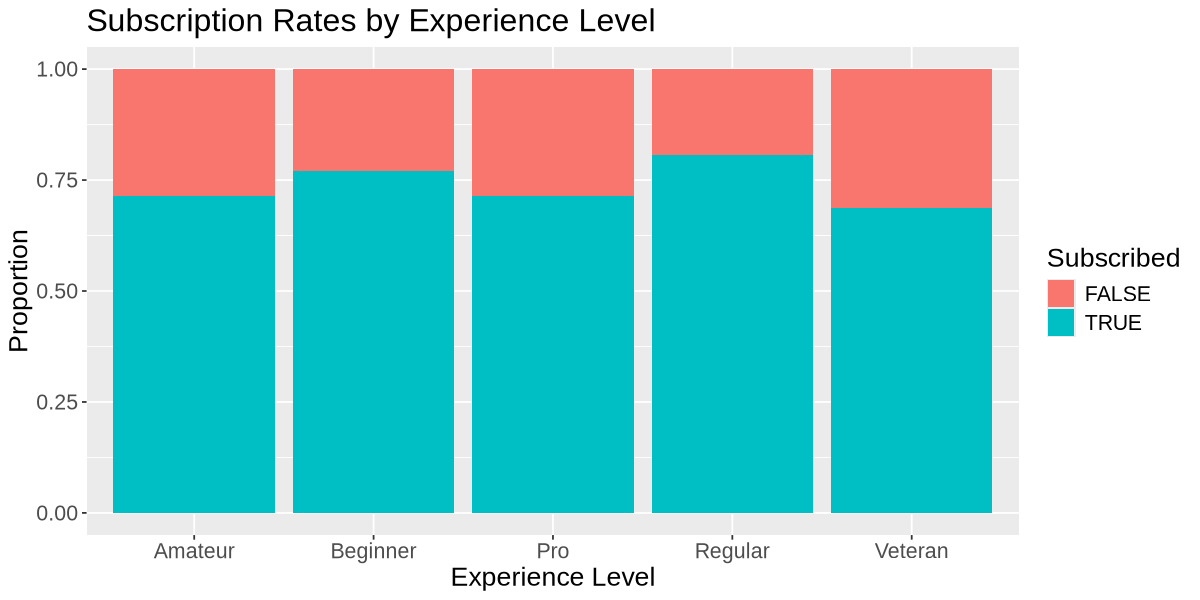

In [20]:
players_data |>
  ggplot(aes(x = experience, fill = subscribe)) +
  geom_bar(position = "fill") +
  labs(title = "Subscription Rates by Experience Level",
       x = "Experience Level",
       y = "Proportion",
       fill = "Subscribed") +
    theme(text = element_text(size = 16))

This graph shows us that subscription rates are generally the same for every experience level, and not increasing or decreasing with more or less experience. You know this probably means we shouldn't use experience as a predictor for whether somebody is subscribed or not.

#### Fig. 2 - Subscription Rates by Age

Warning message:
“Removed 2 rows containing non-finite outside the scale range (`stat_count()`).”


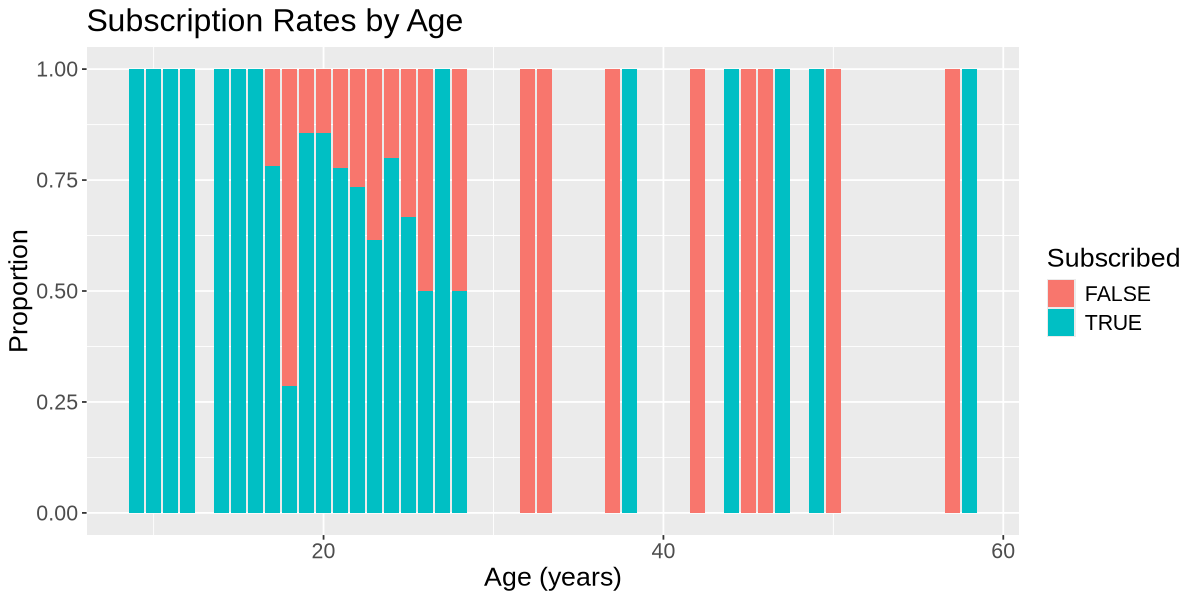

In [15]:
options(repr.plot.height = 5, repr.plot.width = 10)
players_data |>
  ggplot(aes(x = Age, fill = subscribe)) +
  geom_bar(position = "fill") +
  labs(title = "Subscription Rates by Age",
       x = "Age (years)",
       y = "Proportion",
       fill = "Subscribed") +
    theme(text = element_text(size = 16))

We can see that as age increases gradually, the chance of players subscribe game-related newsletters decreases.

#### Fig. 3 - Subscription Rates by Total Amount of Played Hours

Warning message in scale_x_log10():
“log-10 transformation introduced infinite values.”
Warning message:
“Removed 85 rows containing non-finite outside the scale range (`stat_count()`).”
Warning message:
“`position_stack()` requires non-overlapping x intervals.”


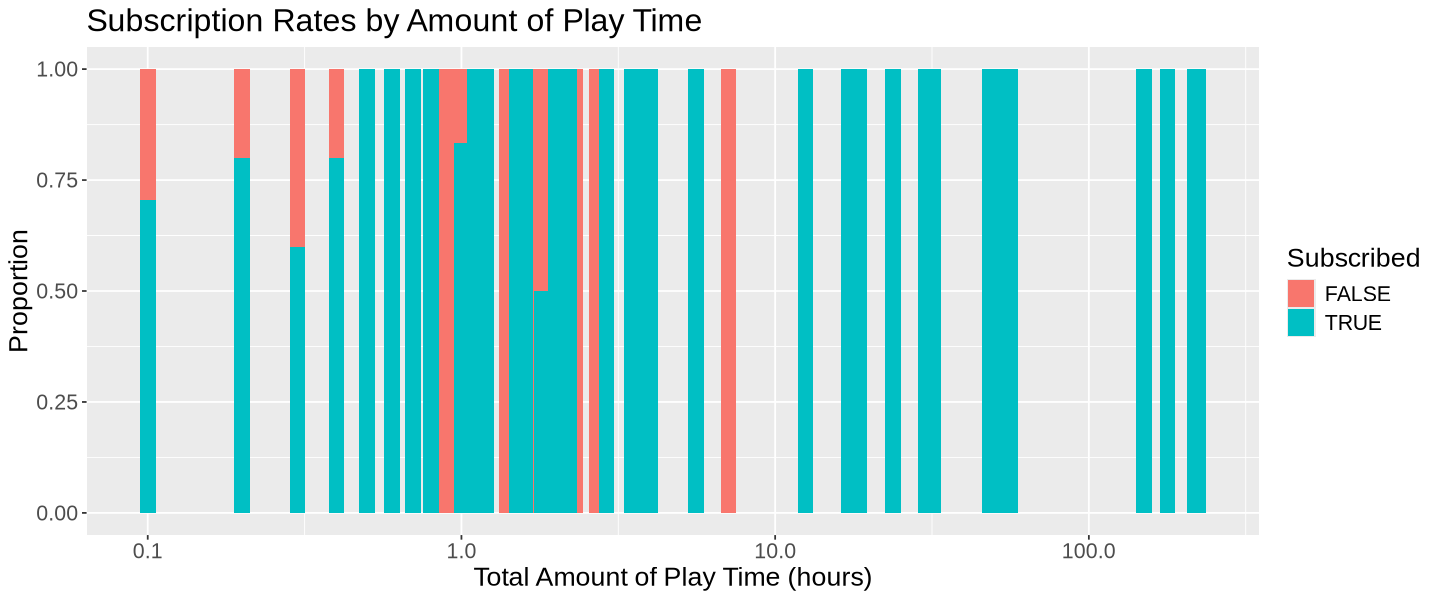

In [34]:
options(repr.plot.height = 5, repr.plot.width = 12)
players_data |>
  ggplot(aes(x = played_hours, fill = subscribe)) +
  geom_bar(width= 0.05) +
  labs(title = "Subscription Rates by Amount of Play Time",
       x = "Total Amount of Play Time (hours)",
       y = "Proportion",
       fill = "Subscribed") +
    scale_x_log10()+
    theme(text = element_text(size = 16))

Here we can see that as the total amount of play time increases generally a player is more likely to be subscribed to the newsletter.

#### Fig. 4 - Age versus Total Play Time Color Coded by Subscription

Warning message in scale_y_log10():
“log-10 transformation introduced infinite values.”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`).”


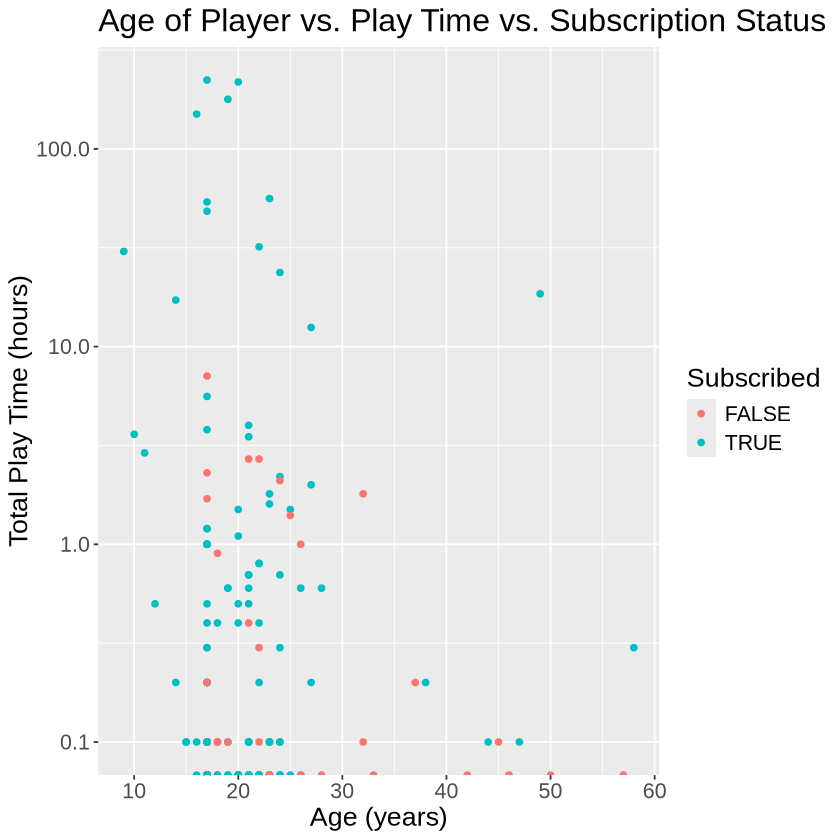

In [11]:
players_data|>
    ggplot( aes(x = Age, y = played_hours, color = subscribe))+
    geom_point()+
    labs(x = "Age (years)",
         y = "Total Play Time (hours)",
         color = "Subscribed",
         title = "Age of Player vs. Play Time vs. Subscription Status")+
    scale_y_log10()+
    theme(text = element_text(size = 16))

I included this last one so that we could get a graph that didn't have wierdly sized bars and it's less confusing, however it's not as easy to see the trends that as age decreases subscription rates increase, and as play time increases subscription rates increase as well. Pick the ones that make the most sense to you.

### 5. Exploratory Data Analysis (EDA)

In [12]:
#do knn classification given played hrs obs and experience level obs to predict subscription status
#no needto step up the sample of non-subscribed people according to the TA since we didn't go over it in detail in the textbook or in class
#train on 75% and test on 25%
set.seed(27)

players_split <- players_wrang|>
    initial_split( prop = 0.75, strata = subscribe)

players_train <- training(players_split)

players_test<- testing(players_split)

#model specification
knn_spec <- nearest_neighbor(weight_func = "rectangular", neighbors = tune())|>
            set_engine("kknn")|>
            set_mode("classification")
#possible parameter values
k_vals<- tibble(neighbors = seq(from = 1, to = 40, by = 2))

#recipe
players_recipe <- recipe(subscribe ~ played_hours + experience + Age, data = players_train)|>
      step_normalize(all_predictors())

#validation via subsetting the training data
players_vfold <- vfold_cv(players_train, v = 10, strata = subscribe)

#results about how well the model predicts subscription status for each K-value
players_results <- workflow()|>
    add_recipe(players_recipe)|>
    add_model(knn_spec)|>
    tune_grid(resamples = players_vfold, grid = k_vals)|>
    collect_metrics()|>
    filter(.metric == "accuracy")

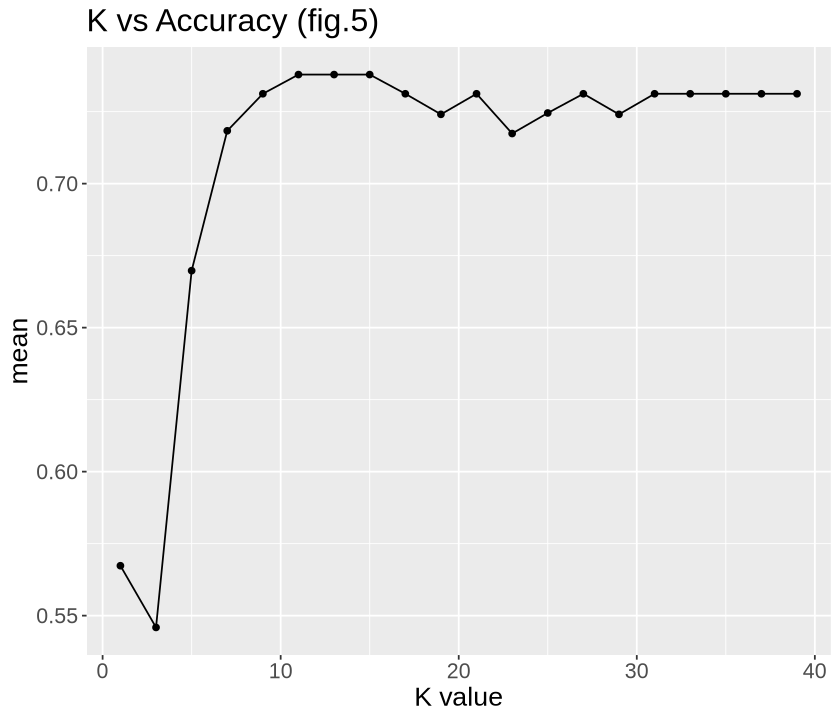

In [13]:
options(repr.plot.height = 6)
K_vs_accuracy <- ggplot(players_results, aes( x= neighbors, y = mean))+
    geom_point()+
    geom_line()+
    labs( x = "K value", title = "K vs Accuracy (fig.5)")+
    theme(text = element_text(size = 16))

K_vs_accuracy

In [14]:
#retrain model based on best parameter value k=11
players_spec <- nearest_neighbor(weight_func = "rectangular", neighbors = 11)|>
    set_engine("kknn")|>
    set_mode("classification")

#test new model on test data 
players_fit <- workflow()|>
    add_recipe(players_recipe)|>
    add_model(players_spec)|>
    fit(data = players_train)

test_predictions <- predict(players_fit, players_test)|>
    bind_cols(players_test)|>
    metrics(truth = subscribe, estimate = .pred_class)|>
    filter(.metric == "accuracy")

test_predictions

.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
accuracy,binary,0.6938776


Basically, the results mean nothing because the accuracy of the predictions is about the same as the proportion of people who are subscribed to the newsletter in the data set with only male players included. 
\
Actually if somebody can go back to the classifcation II notes and figure out what the accuracy metric means and write that down that would be great.